# Step 7 — Project the 11 ST clusters onto chemotherapy cohorts

Applies the Seurat anchor-based transfer of TCGA's 11 ST-cluster labels onto the
chemotherapy-treated PBCP slides (19 slides — the `treatment == "chemo"` subset
of the 37-slide PBCP cohort). The cohort uses its own tuned anchor preset,
distinct from the trastuzumab parameter set (see
[`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R) ::
`TRANSFER_PRESETS$PBCP_Chemo`).

Currently the chemotherapy "cohorts" group has only PBCP; the notebook is set
up so additional chemotherapy cohorts (e.g., TransNEO-Chemo, IMPRESS-Chemo)
can be added later as more rows in the same heatmap section.

**Inputs (committed under `clustering/data/`)**
- `pbcp_query.qs` — PBCP per-domain Seurat object (full 289 domains).

**Outputs (committed under `clustering/data/`)**
- `pbcp_chemo_per_domain.csv` / `pbcp_chemo_cluster_props.csv` (chemo subset).

## Setup

In [1]:
import sys, subprocess
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from clustering_helpers import HEATMAP_ROW_ORDER

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## What are `target` and `query`?

- **`target`** — same TCGA reference Seurat object used across all transfer notebooks
  (notebooks 04–07).
- **`query`** — `pbcp_query.qs`, the PBCP per-domain Seurat object. PBCP holds both
  trastuzumab- and chemo-treated patients in one object; the chemo subset is selected
  by `treatment == "chemo"` after the transfer.

In [2]:
def inspect_qs(qs_path, label):
    res = subprocess.run(
        ["bash", "-c",
         f"source /etc/profile.d/modules.sh 2>/dev/null; "
         f"module load R/4.3.2 2>/dev/null; "
         f"Rscript ../lib/inspect_seurat.R {qs_path} '{label}'"],
        capture_output=True, text=True,
    )
    print("\n".join(l for l in res.stdout.splitlines() if "lscratch" not in l))

# inspect_qs(REFERENCE_QS, "TCGA reference (target)")  # uncomment to run
# inspect_qs("../data/pbcp_query.qs", "PBCP")

## Stage 1 — Project labels

Each cohort uses its own preset. The cell below **actually runs the projection** for the smallest cohort (PBCP, 19 chemo slides). Output goes to `/tmp/...` so it doesn't clobber the committed canonical CSV; the other cohorts follow the same pattern and are kept as commented template calls.

In [3]:
import os
os.makedirs("/tmp/p2s_extended", exist_ok=True)

def run_projection(query_qs, out_csv, preset):
    cmd = (f"source /etc/profile.d/modules.sh 2>/dev/null; "
           f"module load R/4.3.2 2>/dev/null; "
           f"Rscript ../lib/transfer_TCGA_to_external.R "
           f"{REFERENCE_QS} {query_qs} {out_csv} {preset}")
    res = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
    out = "\n".join(l for l in (res.stdout + res.stderr).splitlines()
                       if "lscratch" not in l)
    print(out)
    return out_csv

# Live demo: run the projection for PBCP chemo (~30 s).
recomputed = run_projection(
    query_qs = "../data/pbcp_query.qs",
    out_csv  = "/tmp/p2s_extended/pbcp_chemo_recomputed.csv",
    preset   = "PBCP_Chemo",
)

# Uncomment to run other chemo cohorts:
# run_projection("../data/transneo_query.qs", "/tmp/p2s_extended/transneo_chemo_recomputed.csv", "TransNEO_Chemo")
# run_projection("../data/impress_query.qs",  "/tmp/p2s_extended/impress_chemo_recomputed.csv",  "IMPRESS_Chemo")

Cohort: PBCP_Chemo
Loading reference: /vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs
Loading query:     ../data/pbcp_query.qs
Running label transfer...
Aggregating to per-patient × per-cluster proportions...
Wrote 37 patients to /tmp/p2s_extended/pbcp_chemo_recomputed.csv
Performing PCA on the provided reference using 723 features as input.
Projecting cell embeddings
Finding neighborhoods
Finding anchors
	Found 27032 anchors
Filtering anchors
	Retained 19533 anchors
Finding integration vectors
Finding integration vector weights
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Predicting cell labels


### Sanity check — recomputed vs committed

PBCP-chemo here uses the FULL PBCP Seurat object (both arms = 289 domains) with the chemo preset; the canonical CSV holds the chemo subset only (`treatment == "chemo"`, 154 domains → 19 patients). The L1 distance below compares them on the common patients.

In [4]:
mine = pd.read_csv(recomputed, index_col=0)
canon = pd.read_csv("../data/pbcp_chemo_cluster_props.csv", index_col=0)
both = mine.index.intersection(canon.index)
diff = (mine.loc[both] - canon.loc[both]).abs().sum().sum() if len(both) else float("nan")
print(f"shapes: mine={mine.shape}, canonical={canon.shape}, common patients={len(both)}")
print(f"L1 distance between recomputed and committed (chemo patients only): {diff:.4f}")

shapes: mine=(37, 11), canonical=(19, 11), common patients=19
L1 distance between recomputed and committed (chemo patients only): 2.3985


## Stage 2 — Load committed cohort CSVs and draw heatmaps

In [5]:
cohort_files = {
    "PBCP — chemo":         "../data/pbcp_chemo_cluster_props.csv",
    "TransNEO — chemo":     "../data/transneo_chemo_cluster_props.csv",
    "IMPRESS — chemo":      "../data/impress_chemo_cluster_props.csv",
}
for label, f in cohort_files.items():
    print(f"{label:<25} {len(pd.read_csv(f, index_col=0)):>4} patients")

PBCP — chemo                19 patients
TransNEO — chemo            93 patients
IMPRESS — chemo             64 patients


In [6]:
def _zscore_rows(M):
    mu = M.mean(axis=1, keepdims=True); s = M.std(axis=1, keepdims=True)
    s[s == 0] = 1
    return (M - mu) / s

def draw_cohort_heatmap(props_csv, title, max_cols=None):
    df = pd.read_csv(props_csv, index_col=0)
    df = df.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
    # Order patients by Ward dendrogram across all 11 clusters
    from scipy.cluster.hierarchy import linkage, leaves_list
    sub_mat = df[HEATMAP_ROW_ORDER].values
    if len(df) > 1:
        order = leaves_list(linkage(sub_mat, method="ward"))
    else:
        order = np.arange(len(df))
    raw = df.iloc[order][HEATMAP_ROW_ORDER].T.values
    heat = _zscore_rows(raw)

    from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
    v_lo, v_mid, v_hi = float(heat.min()), 2.85, float(heat.max())
    cmap = LinearSegmentedColormap.from_list(
        "viridis3", plt.get_cmap("viridis")(np.linspace(0, 1, 3)), N=256
    )
    norm = TwoSlopeNorm(vmin=v_lo, vcenter=min(v_mid, v_hi - 1e-6), vmax=v_hi)

    fig = plt.figure(figsize=(max(4.2, 0.18 * heat.shape[1] + 2), 3.0))
    gs  = gridspec.GridSpec(1, 2, figure=fig,
                             width_ratios=[60, 1], hspace=0.05, wspace=0.02)
    ax_h = fig.add_subplot(gs[0, 0])
    im = ax_h.imshow(heat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
    ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
    ax_h.set_xticks([]); ax_h.tick_params(left=False)
    ax_h.set_title(title, fontsize=8)
    ax_cb = fig.add_subplot(gs[0, 1])
    plt.colorbar(im, cax=ax_cb).set_label("Z-score", fontsize=7)
    ax_cb.tick_params(labelsize=6)
    plt.show()

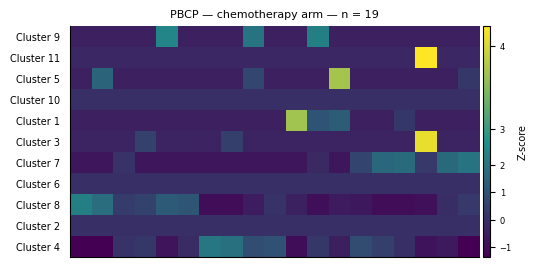

In [7]:
draw_cohort_heatmap("../data/pbcp_chemo_cluster_props.csv",
                    f"PBCP — chemotherapy arm — n = {len(pd.read_csv('../data/pbcp_chemo_cluster_props.csv', index_col=0))}")

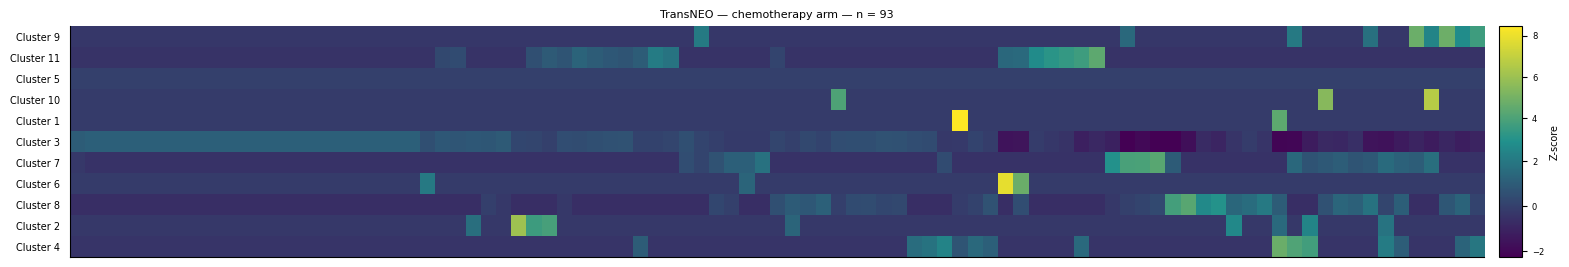

In [8]:
draw_cohort_heatmap("../data/transneo_chemo_cluster_props.csv",
                    f"TransNEO — chemotherapy arm — n = {len(pd.read_csv('../data/transneo_chemo_cluster_props.csv', index_col=0))}")

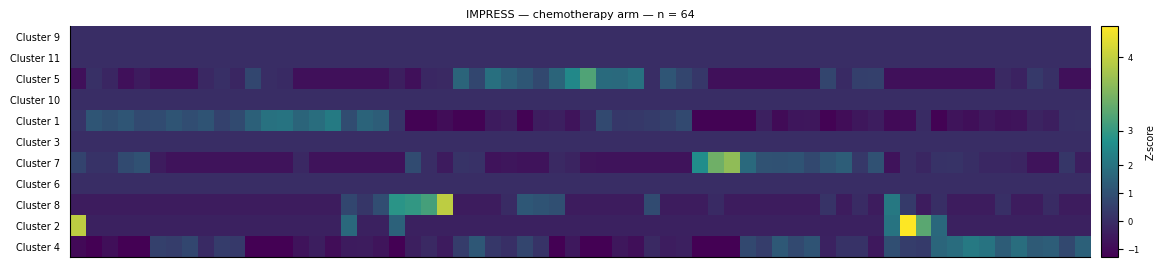

In [9]:
draw_cohort_heatmap("../data/impress_chemo_cluster_props.csv",
                    f"IMPRESS — chemotherapy arm — n = {len(pd.read_csv('../data/impress_chemo_cluster_props.csv', index_col=0))}")